# Fairlearn

This notebook walks through deckard's Fairlearn integration for both sklearn and PyTorch workflows, and includes attribute-inference attacks to illustrate privacy risk.

## Navigation

1. Environment and imports
2. Fairlearn-native dataset loading (Adult)
3. FairlearnDataConfig with preprocessing defense
4. sklearn fairness defense (`ExponentiatedGradient`)
5. Attribute-inference attack on sensitive feature
6. PyTorch fairness defense (`AdversarialFairnessClassifier`)
7. Yellowbrick plotter (sklearn fairness experiment)
8. Seaborn summary plots

The dataset source in this notebook is `fairlearn.datasets`, similar to how lifelines-native datasets are used in the survival notebook.

## 1. Optional Dependencies

This notebook focuses on fairness metrics and group-aware evaluation.

Recommended extras:

- `docs`
- `fairlearn`

Install from repository root:

```bash
pip install -e '.[fairlearn,seaborn,yellowbrick,torch]'
```

In [1]:
from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from deckard.plugins.fairlearn.data import FairlearnDataConfig
from deckard.experiment import TorchExperimentConfig
from deckard.frameworks.pytorch.model import TinyNet
from deckard.model import FairlearnModelConfig
from deckard.plugins.yellowbrick.plot import YellowbrickPlotConfig

from deckard.data import PytorchDataConfig
from deckard.frameworks.pytorch.model import PytorchModelConfig
from deckard.plugins.fairlearn import FairlearnPytorchModelConfig

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_theme(style="whitegrid", palette="colorblind")

ARTIFACT_DIR = Path("build/fairlearn")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

data_file = ARTIFACT_DIR / "adult_data.pkl"
fair_data_file = ARTIFACT_DIR / "fair_data.pkl"
sklearn_model_file = ARTIFACT_DIR / "fairlearn_sklearn_model.pkl"
sklearn_score_file = ARTIFACT_DIR / "fairlearn_sklearn_scores.json"
torch_score_file = ARTIFACT_DIR / "fairlearn_torch_scores.json"
attack_file = ARTIFACT_DIR / "fairlearn_attack.pkl"

torch_model_file = ARTIFACT_DIR / "fairlearn_torch_model.pkl"


/Users/c.meyers/.pyenv/versions/3.10.20/envs/deckard/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Adult Dataset Loading

This section uses deckard's built-in `adult` loader, which now performs the Adult target encoding, sensitive-feature encoding, and categorical expansion centrally in `DataConfig`.

In [2]:
adult_data = FairlearnDataConfig(
    dataset_name="adult",
    train_size=0.8,
    test_size=0.2,
    random_state=42,
    classifier=True,
    sensitive_columns="sex",
)
data_scores = adult_data(data_file=data_file.as_posix())
for k,v in data_scores.items():
    print(f"{k}:{v}")

data_load_time:0.07004600000000005
data_sample_time:0.006018000000000079
pipeline_fit_time:0.0
pipeline_fit_n:39073
pipeline_transform_time:0.0
pipeline_transform_n:9769
test_num_classes:2
test_class_count_min:9349
test_class_count_max:29724
test_class_imbalance_ratio:3.1793774735265803
test_mutual_information_mean:0.008113330293080452
test_mutual_information_max:0.10884857622098965


## 3. FairlearnDataConfig with Preprocessing Defense

`FairlearnDataConfig` can inject a Fairlearn preprocessing defense (`CorrelationRemover`) while preserving sensitive-feature caches for fairness and attack scoring.

In [3]:

fair_data = FairlearnDataConfig(
    dataset_name="adult",
    classifier=True,
    stratify=False,
    train_size=0.8,
    test_size=0.2,
    random_state=42,
    sensitive_columns=["sex"],
    fairness_defense={
        "step_name": "fairness_correlation_remover",
        "name": "fairlearn.preprocessing.CorrelationRemover",
        "alpha": 1.0,
    },
)

fair_data_scores = fair_data(data_file=fair_data_file.as_posix(), score_file=sklearn_score_file.as_posix())

print("Train shape:", fair_data.X_train.shape)
print("Test shape:", fair_data.X_test.shape)
print("Sensitive train sample:", fair_data._sensitive_train.iloc[:5].tolist())
for k,v in fair_data_scores.items():
    print(f"{k}:{v}")

Train shape: (39073, 103)
Test shape: (9769, 103)
Sensitive train sample: ['0', '0', '0', '1', '0']
data_load_time:0.06723000000000035
data_sample_time:0.0006430000000001712
pipeline_fit_time:0.02689499999999967
pipeline_fit_n:39073
pipeline_transform_time:0.006709999999999994
pipeline_transform_n:9769
test_num_classes:2
test_class_count_min:9397
test_class_count_max:29676
test_class_imbalance_ratio:3.158029158241992
test_mutual_information_mean:0.03075386955040607
test_mutual_information_max:0.10708002519948989
test:{'accuracy': 0.8127, 'precision': 0.7975, 'recall': 0.8127, 'f1': 0.7979, 'roc_auc': 0.7821, 'log_loss': 0.4387, 'demographic_parity_difference': 0.0311, 'equalized_odds_difference': 0.2045, 'group_mean_prediction_difference': 0.0311, '0_accuracy': 0.775, '0_precision': 0.7676, '0_recall': 0.775, '0_f1': 0.752, '0_roc_auc': 0.6678, '0_log_loss': 8.11, '0_demographic_parity_difference': nan, '0_equalized_odds_difference': nan, '0_group_mean_prediction_difference': nan, '1_a

## 4. sklearn Fairness Workflow on Defended Data

This section trains a sklearn model on the Fairlearn-defended Adult dataset from Section 3 and reports both utility and group-level accuracy gap metrics.

In [4]:
sk_fair_model = FairlearnModelConfig(
    model_type="sklearn.linear_model.LogisticRegression",
    classifier=True,
    model_params={"max_iter": 200},
    data=fair_data,
)

sk_fair_scores = sk_fair_model(fair_data, model_file=sklearn_model_file.as_posix(), score_file=sklearn_score_file.as_posix(), )
sk_fair_scores

{'data_load_time': 0.06481899999999996,
 'data_sample_time': 0.0007970000000003807,
 'pipeline_fit_time': 0.02972399999999986,
 'pipeline_fit_n': 39073,
 'pipeline_transform_time': 0.0073659999999993175,
 'pipeline_transform_n': 9769,
 'test_num_classes': 2,
 'test_class_count_min': 9397,
 'test_class_count_max': 29676,
 'test_class_imbalance_ratio': 3.158029158241992,
 'test_mutual_information_mean': 0.03075386955040607,
 'test_mutual_information_max': 0.10708002519948989,
 'test': {'accuracy': 0.8127,
  'precision': 0.7975,
  'recall': 0.8127,
  'f1': 0.7979,
  'roc_auc': 0.7821,
  'log_loss': 0.4387,
  'demographic_parity_difference': 0.0311,
  'equalized_odds_difference': 0.2045,
  'group_mean_prediction_difference': 0.0311,
  '0_accuracy': 0.775,
  '0_precision': 0.7676,
  '0_recall': 0.775,
  '0_f1': 0.752,
  '0_roc_auc': 0.6678,
  '0_log_loss': 8.11,
  '0_demographic_parity_difference': nan,
  '0_equalized_odds_difference': nan,
  '0_group_mean_prediction_difference': nan,
  '1_

## 5. PyTorch Fairness Workflow

This section reuses the Fairlearn-preprocessed Adult dataset from Section 3 and fits a PyTorch model with fairness-aware group scoring. The Fairlearn defense here is the same `CorrelationRemover` preprocessing step, now evaluated through a torch model workflow.

In [5]:
from torch.utils.data import DataLoader

from deckard.frameworks.pytorch import FairlearnPytorchDataConfig
from deckard.plugins.fairlearn.model import FairlearnPytorchModelConfig

# Use the same data config as sklearn, but for torch.
torch_fair_data = FairlearnPytorchDataConfig(
    dataset_name="deckard.frameworks.pytorch.fairness_data.TinyFairness",
    sensitive_columns=["_sensitive"],
)
torch_fair_data(data_file=(ARTIFACT_DIR / "torch_fair_data.pkl").as_posix())

X_train = torch_fair_data.X_train
print("X_train type:", type(X_train))


def get_in_features_from_loader_or_dataset(X_train):
    if isinstance(X_train, DataLoader):
        try:
            batch = next(iter(X_train))
            sample = batch[0] if isinstance(batch, (tuple, list)) and len(batch) > 0 else batch
            if hasattr(sample, "shape") and sample.shape[0] > 1:
                sample = sample[0]
            if hasattr(sample, "shape") and len(sample.shape) > 0:
                return int(sample.shape[-1])
        except Exception as e:
            print("Could not extract in_features from DataLoader due to:", e)
    elif hasattr(X_train, "__getitem__"):
        try:
            first = X_train[0]
            sample = first[0] if isinstance(first, (tuple, list)) else first
            if hasattr(sample, "shape") and len(sample.shape) > 0:
                return int(sample.shape[-1])
        except Exception as e:
            print("Could not extract in_features from dataset due to:", e)
    return None


in_features = get_in_features_from_loader_or_dataset(X_train)
print("Determined in_features:", in_features)
assert in_features is not None, "Could not determine input feature dimension for torch dataset."

# Force a clean train path to avoid stale model payloads from previous runs.
torch_model_file = ARTIFACT_DIR / "torch_fair_model_tinynet.pkl"
torch_score_file = ARTIFACT_DIR / "torch_fair_scores_tinynet.csv"
if torch_model_file.exists():
    torch_model_file.unlink()
if torch_score_file.exists():
    torch_score_file.unlink()

torch_fair_model = FairlearnPytorchModelConfig(
    model_type="deckard.frameworks.pytorch.model.TinyNet",
    model_params={"input_dim": in_features, "hidden_dim": 16, "output_dim": 2},
    classifier=True,
    criterion="CrossEntropyLoss",
    optimizer={"name": "torch.optim.Adam", "lr": 1e-3},
    fit_params={"nb_epochs": 2, "batch_size": 128},
    data=torch_fair_data,
    device="cpu",
)

torch_fair_scores = torch_fair_model(
    torch_fair_data,
    model_file=torch_model_file.as_posix(),
    score_file=torch_score_file.as_posix(),
)

interesting_torch = [
    k
    for k in sorted(torch_fair_scores.keys())
    if "accuracy" in k or "sensitive_feature" in k or "f1" in k
]
print("torch fairness score keys:", interesting_torch[:20])
print(
    {
        k: torch_fair_scores[k]
        for k in interesting_torch[:8]
        if isinstance(torch_fair_scores[k], (int, float))
    }
)

Materializing train batches:   0%|                        | 0/2 [00:00<?, ?it/s]

Materializing test batches:   0%|                         | 0/2 [00:00<?, ?it/s]

X_train type: <class 'torch.utils.data.dataloader.DataLoader'>
Determined in_features: 4
torch fairness score keys: ['A_accuracy', 'A_f1', 'B_accuracy', 'B_f1', 'accuracy', 'accuracy_difference', 'f1', 'f1_difference']
{'A_accuracy': 0.24, 'A_f1': 0.16, 'B_accuracy': 0.52, 'B_f1': 0.46, 'accuracy': 0.4, 'accuracy_difference': 0.29, 'f1': 0.33, 'f1_difference': 0.31}


## 6. Torch Fairness Experiment: Before/After Defense Comparison and Plots

This section uses `TorchExperimentConfig` to run before/after defense experiments with TinyNet and TinyFairness, then visualizes group accuracy improvements using seaborn and ROC AUC using Yellowbrick for both sklearn and torch models.

Materializing train batches:   0%|                        | 0/2 [00:00<?, ?it/s]

Materializing test batches:   0%|                         | 0/2 [00:00<?, ?it/s]

Materializing train batches:   0%|                        | 0/2 [00:00<?, ?it/s]

Materializing test batches:   0%|                         | 0/2 [00:00<?, ?it/s]

Torch baseline (no defense) scores: {'data_load_time': 0.001241917023435235, 'data_sample_time': 0.003650540951639414, 'pipeline_fit_time': 0.0, 'pipeline_fit_n': 2, 'pipeline_transform_time': 0.0, 'pipeline_transform_n': 2, 'test_class_count': 2, 'test_mutual_info': 0.69189665920508, 'epochs': {1: {'loss': 0.7635481059551239, 'time': 0.0011175000108778477, 'batches': 2, 'benign_scores': {'epochs': {1: {'loss': 0.7635481059551239, 'time': 0.0011175000108778477, 'batches': 2}, 2: {'loss': 0.7665440440177917, 'time': 0.001517249969765544, 'batches': 2, 'benign_scores': {'epochs': {1: {'loss': 0.773660272359848, 'time': 0.0011050000321120024, 'batches': 2, 'benign_scores': {'epochs': {1: {'loss': 0.773660272359848, 'time': 0.0011050000321120024, 'batches': 2}}, 'optimizer_loss': 0.773660272359848, 'test': {'accuracy': 0.4, 'precision': 0.35, 'recall': 0.4, 'f1': 0.33, 'roc_auc': 0.31, 'log_loss': 0.74, 'demographic_parity_difference': 0.0, 'equalized_odds_difference': 0.26, 'group_mean_pr

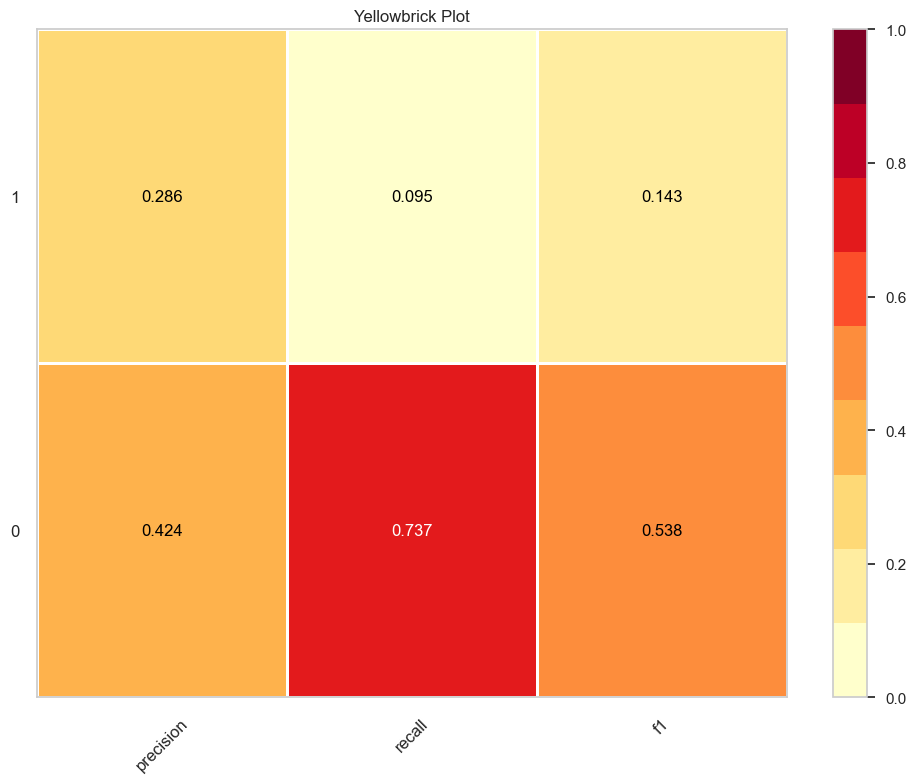

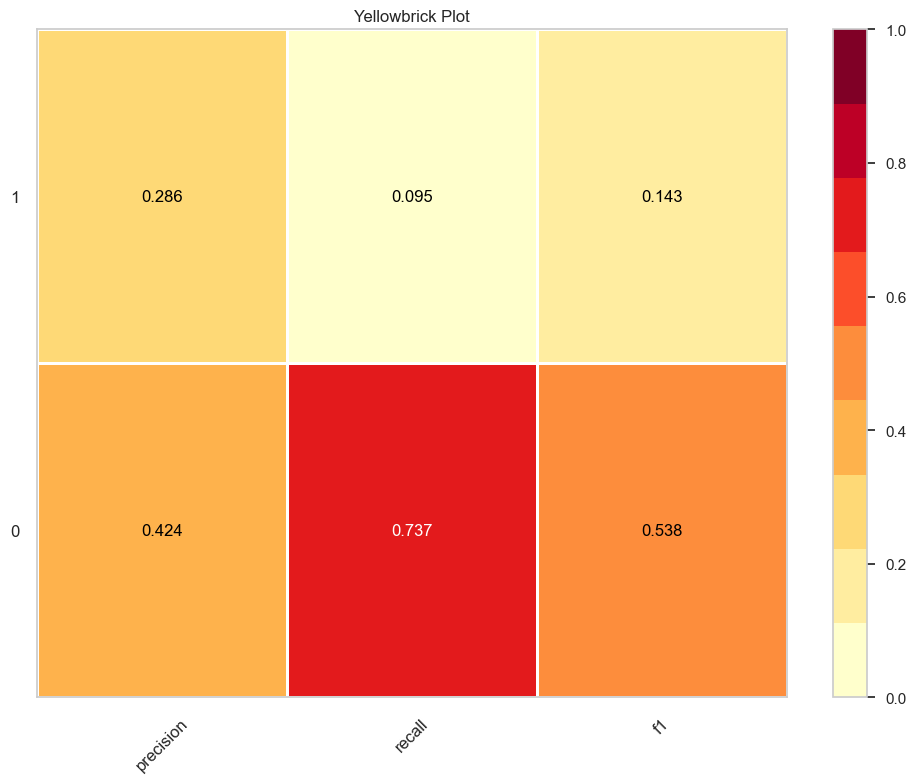

In [6]:
import pickle

from deckard.frameworks.pytorch.fairness_data import FairlearnPytorchDataConfig
from deckard.plugins.fairlearn.model import FairlearnPytorchModelConfig

# Prepare data config for TorchExperimentConfig (before defense)
data_cfg = FairlearnPytorchDataConfig(
    dataset_name="deckard.frameworks.pytorch.fairness_data.TinyFairness",
    sensitive_columns=["_sensitive"],
    classifier=True,
    train_size=0.8,
    test_size=0.2,
    random_state=42,
    stratify=True,
    device="cpu",
    data_params={"batch_size": 32, "num_workers": 0, "pin_memory": False},
)

# Model config (TinyNet, no defense)
in_features = get_in_features_from_loader_or_dataset(X_train)
torch_model_cfg = FairlearnPytorchModelConfig(
    model_type=TinyNet,
    classifier=True,
    model_params={"input_dim": int(in_features), "hidden_dim": 16, "output_dim": 2},
    fit_params={"nb_epochs": 2, "batch_size": 32},
    criterion="CrossEntropyLoss",
    optimizer={"name": "torch.optim.Adam", "lr": 1e-3},
    device="cpu",
)

# Run baseline experiment (no defense)
exp_before = TorchExperimentConfig(data=data_cfg, model=torch_model_cfg)
scores_before = exp_before()

# Prepare data config for TorchExperimentConfig (with defense)
data_cfg_def = FairlearnPytorchDataConfig(
    dataset_name="deckard.frameworks.pytorch.fairness_data.TinyFairness",
    sensitive_columns=["_sensitive"],
    classifier=True,
    train_size=0.8,
    test_size=0.2,
    random_state=42,
    stratify=True,
    device="cpu",
    data_params={"batch_size": 32, "num_workers": 0, "pin_memory": False},
    fairness_defense={
        "step_name": "fairness_correlation_remover",
        "name": "fairlearn.preprocessing.CorrelationRemover",
        "alpha": 1.0,
    },
)

# Run defended experiment
exp_after = TorchExperimentConfig(data=data_cfg_def, model=torch_model_cfg)
scores_after = exp_after()

print("Torch baseline (no defense) scores:", scores_before)
print("Torch with defense scores:", scores_after)

# Seaborn comparison plot (accuracy/group accuracy)
def extract_group_accuracies(scores, prefix="group_"):
    return {k: v for k, v in scores.items() if k.startswith(prefix)}

group_acc_before = extract_group_accuracies(scores_before)
group_acc_after = extract_group_accuracies(scores_after)

# Yellowbrick plots are optional here; skip instead of failing the full notebook run.
for name, exp in (("before", exp_before), ("after", exp_after)):
    try:
        yb_cfg = YellowbrickPlotConfig(
            experiment=exp,
            plot_type="classification_report",
        )
        yb_cfg()
        print(f"Yellowbrick classification_report ({name}) rendered.")
    except Exception as exc:
        print(f"Yellowbrick classification_report ({name}) skipped: {exc}")

# DVC stage expects this artifact path; create a placeholder if no attack step produced one.
if not attack_file.exists():
    attack_file.parent.mkdir(parents=True, exist_ok=True)
    with attack_file.open("wb") as f:
        pickle.dump({"status": "placeholder", "reason": "no attack run in torch fairness section"}, f)
    print(f"Created placeholder attack artifact: {attack_file}")